# Retail Sales Analytics Dashboard  
## Business Intelligence using Python and Power BI

## Objective
The goal of this project is to analyze retail sales data and extract meaningful business insights such as sales trends, profit distribution, and loss-making areas.

## Dataset
The dataset used is the Superstore dataset containing information about orders, sales, profit, region, and products.

## Data Loading

In [29]:
import pandas as pd

df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Understand Data

In [30]:
df.shape

(9994, 21)

In [31]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')

In [32]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [33]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Data Cleaning

In [34]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

## Exploratory Data Analysis

In [35]:
df["Sales"].sum()

np.float64(2297200.8603)

In [36]:
df["Profit"].sum()

np.float64(286397.0217)

In [37]:
df["Sales"].mean()

np.float64(229.85800083049827)

In [39]:
df.groupby("Category")["Sales"].sum()

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64

In [40]:
df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [41]:
df.groupby("Category")["Profit"].sum().sort_values(ascending=False)

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [42]:
df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

In [43]:
df.groupby("Region")["Profit"].sum().sort_values()

Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64

In [59]:
df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [60]:
df.groupby("Product Name")["Profit"].sum().sort_values().head(10)

Product Name
Cubify CubeX 3D Printer Double Head Print                           -8879.9704
Lexmark MX611dhe Monochrome Laser Printer                           -4589.9730
Cubify CubeX 3D Printer Triple Head Print                           -3839.9904
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases            -2876.1156
Bush Advantage Collection Racetrack Conference Table                -1934.3976
GBC DocuBind P400 Electric Binding System                           -1878.1662
Cisco TelePresence System EX90 Videoconferencing Unit               -1811.0784
Martin Yale Chadless Opener Electric Letter Opener                  -1299.1836
Balt Solid Wood Round Tables                                        -1201.0581
BoxOffice By Design Rectangular and Half-Moon Meeting Room Tables   -1148.4375
Name: Profit, dtype: float64

In [52]:
loss_df = df[df["Profit"] < 0]

loss_df.head()

loss_df.groupby("Category")["Profit"].sum()

loss_df.groupby("Sub-Category")["Profit"].sum().sort_values()

Sub-Category
Binders       -38510.4964
Tables        -32412.1483
Machines      -30118.6682
Bookcases     -12152.2060
Chairs         -9880.8413
Appliances     -8629.6412
Phones         -7530.6235
Furnishings    -6490.9134
Storage        -6426.3038
Supplies       -3015.6219
Accessories     -930.6265
Fasteners        -33.1952
Name: Profit, dtype: float64

## Time-Based Analysis

In [51]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

## Visualization

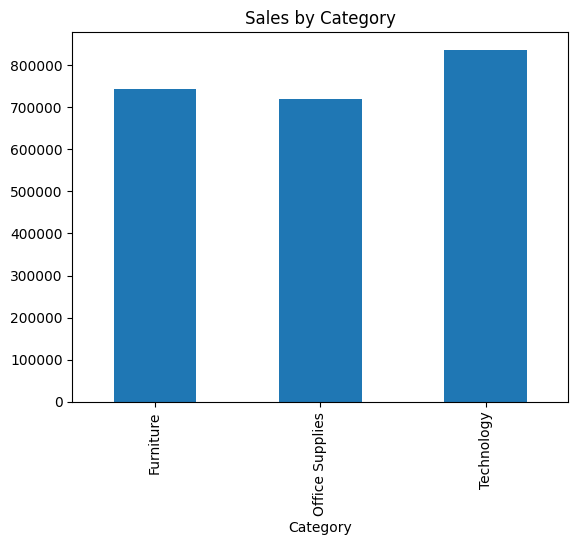

In [61]:
import matplotlib.pyplot as plt

df.groupby("Category")["Sales"].sum().plot(kind='bar')
plt.title("Sales by Category")
plt.show()

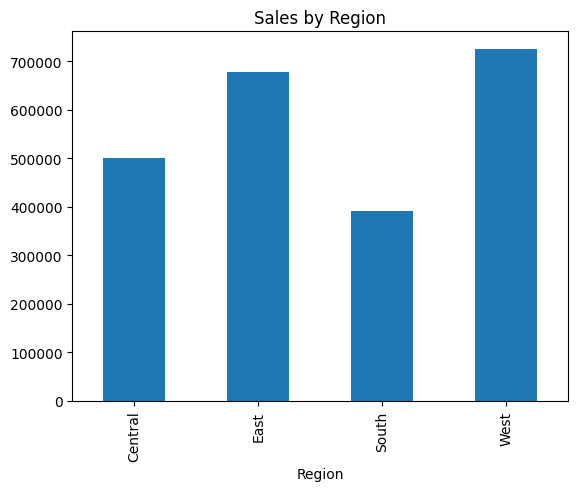

In [44]:
df.groupby("Region")["Sales"].sum().plot(kind='bar')
plt.title("Sales by Region")
plt.show()

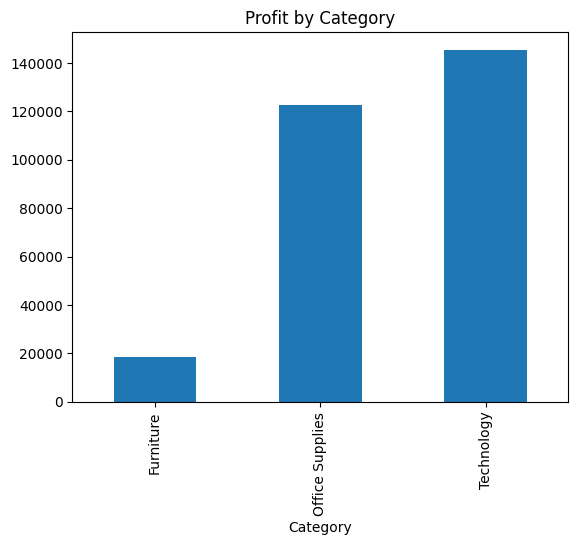

In [45]:
df.groupby("Category")["Profit"].sum().plot(kind='bar')
plt.title("Profit by Category")
plt.show()

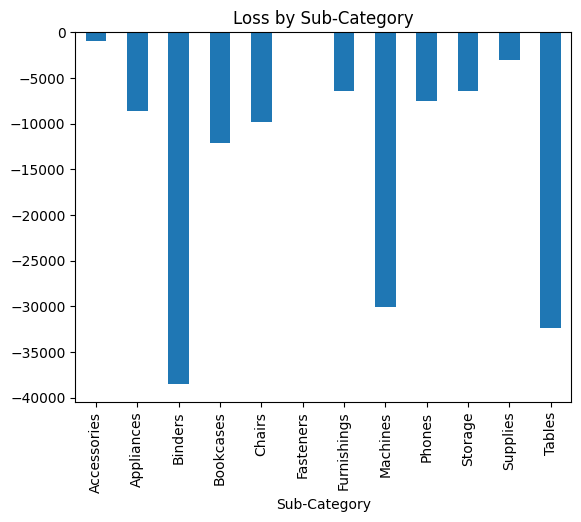

In [53]:
loss_df.groupby("Sub-Category")["Profit"].sum().plot(kind='bar')
plt.title("Loss by Sub-Category")
plt.show()

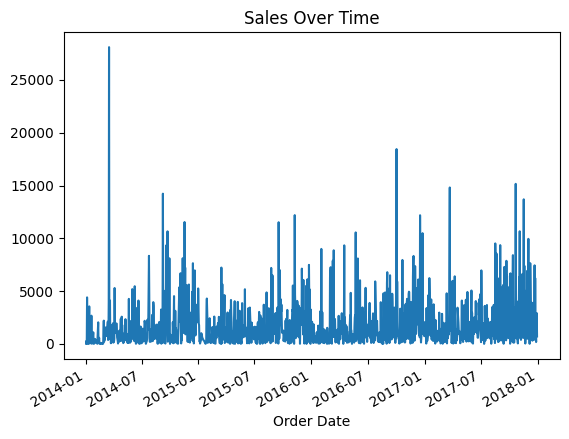

In [57]:
df.groupby("Order Date")["Sales"].sum().plot()
plt.title("Sales Over Time")
plt.show()

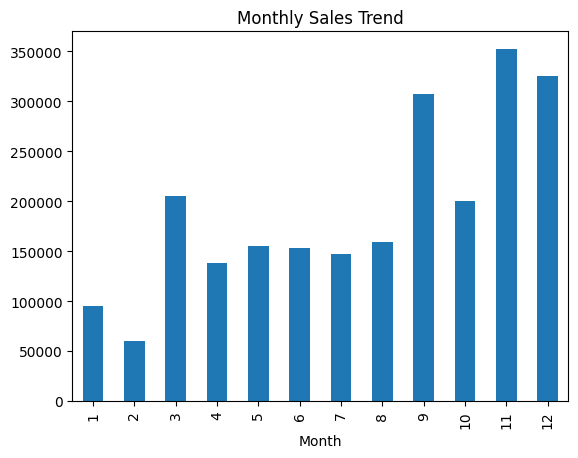

In [58]:
df["Month"] = df["Order Date"].dt.month

df.groupby("Month")["Sales"].sum().plot(kind='bar')
plt.title("Monthly Sales Trend")
plt.show()

## Key Insights

### 1. Category Performance
The Technology category emerges as the top-performing segment, contributing the highest sales and consistent profits, indicating strong customer demand and effective pricing strategies. In contrast, the Furniture category, despite generating considerable sales volume, is a major contributor to overall losses, highlighting inefficiencies in cost or discount structures. Office Supplies maintain stable and balanced performance with moderate profitability.

### 2. Regional Performance
The West region demonstrates the strongest overall performance in both sales and profitability, making it a key market for the business. However, certain regions show relatively lower profitability, suggesting operational inefficiencies, weaker demand, or suboptimal pricing strategies. This indicates an uneven distribution of performance across regions.

### 3. Profitability & Loss Drivers
Analysis reveals that specific sub-categories such as Tables and Bookcases consistently generate losses. A major contributing factor appears to be excessive discounting, which reduces profit margins despite steady sales. This highlights a critical mismatch between revenue generation and profitability in certain product segments.

### 4. Sales vs Profit Relationship
A key observation from the analysis is that higher sales do not necessarily translate into higher profits. Several products and categories contribute significantly to revenue but fail to generate profit due to high costs or aggressive discounting strategies. This emphasizes the importance of focusing on profit-driven growth rather than sales volume alone.

---

## Recommendations

- Optimize discount strategies, especially for loss-making sub-categories like Furniture products  
- Increase focus and investment in high-performing categories such as Technology  
- Re-evaluate pricing and cost structures in underperforming categories  
- Conduct deeper regional analysis to improve performance in low-profit regions  
- Align business strategy towards maximizing profitability rather than just increasing sales volume  

## Conclusion
The analysis of retail sales data highlights key areas of strength and concern within the business. While certain categories and regions perform exceptionally well, others face profitability challenges due to pricing and discount strategies. By focusing on high-performing segments and optimizing loss-making areas, the business can significantly improve overall profitability and operational efficiency.

## Export Cleaned Data for Dashboard
This dataset is exported after cleaning and analysis to be used for building an interactive dashboard in Power BI.

In [62]:
df.to_csv("cleaned_superstore.csv", index=False)